<a href="https://colab.research.google.com/github/moralesalessandra29-crypto/LABORATORIO-DE-PDI/blob/main/P8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 5 - Tipos de Traslaciones de Imágenes**

* 2055762 Alondra María Cruz Castillo
* 2063509 Alessandra Morales Vázquez

In [ ]:
# Librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Parte 1.- Filtros con Máscaras Espaciales Personalizadas**


---



Se carga una imagen de Rayos X en escala de grises, aplicando 3 filtros diferentes de suavizado, cada uno con un valor diferente de kernel.

Mounted at /content/drive


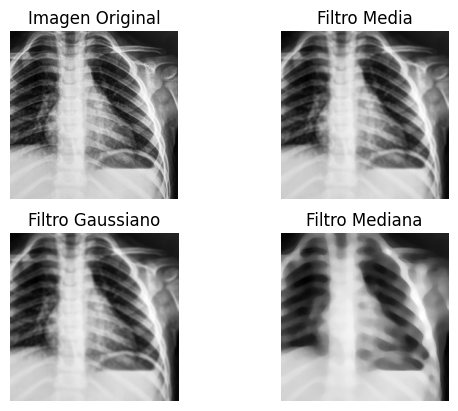

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Cargar imagen en escala de grises
ruta = "/content/drive/MyDrive/PDI/Xray.jpg"

img = cv2.imread(ruta, 0)
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

# Aplicación de filtro de suavizado (media)
f_media = cv2.blur(img, (3, 3))
plt.subplot(2, 2, 2)
plt.imshow(f_media, cmap='gray')
plt.title('Filtro Media')
plt.axis('off')

# Aplicación de filtro de suavizado (gaussiano)
f_gauss = cv2.GaussianBlur(img, (5, 5), 0)
plt.subplot(2, 2, 3)
plt.imshow(f_gauss, cmap='gray')
plt.title('Filtro Gaussiano')
plt.axis('off')

# Aplicación de filtro de suavizado (mediana)
f_mediana = cv2.medianBlur(img, 11)
plt.subplot(2, 2, 4)
plt.imshow(f_mediana, cmap='gray')
plt.title('Filtro Mediana')
plt.axis('off')

plt.show()

A continuación, se aplican 3 filtros más para la detección de bordes en diferentes ejes.

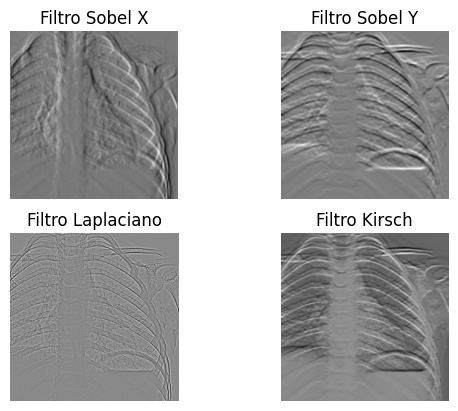

In [ ]:
# Aplicación de filtro de detección de bordes (Sobel en X y Y)
f_sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
plt.subplot(2, 2, 1)
plt.imshow(f_sobelx, cmap='gray')
plt.title('Filtro Sobel X')
plt.axis('off')
f_sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
plt.subplot(2, 2, 2)
plt.imshow(f_sobely, cmap='gray')
plt.title('Filtro Sobel Y')
plt.axis('off')

# Aplicación de filtro de detección de bordes (Laplaciano)
f_laplace = cv2.Laplacian(img, cv2.CV_64F)
plt.subplot(2, 2, 3)
plt.imshow(f_laplace, cmap='gray')
plt.title('Filtro Laplaciano')
plt.axis('off')

# Aplicación de filtro de detección de bordes (Kirsch)
kernel_kirsch = np.array([[2, 2, 2], [-1, 0, -1], [-1, -1, -1]])
f_kirsch = cv2.filter2D(img, cv2.CV_64F, kernel_kirsch)
plt.subplot(2, 2, 4)
plt.imshow(f_kirsch, cmap='gray')
plt.title('Filtro Kirsch')
plt.axis('off')

plt.show()

Se aplica una máscara personalizada para la detección de bordes.

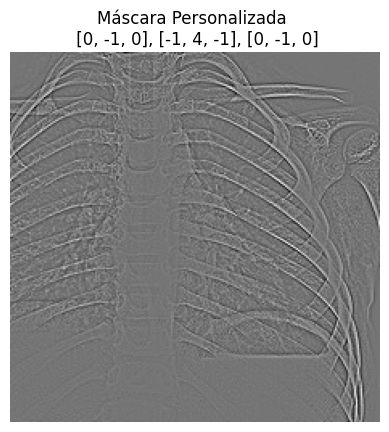

In [ ]:
# Filtro de detección de bordes con máscara personalizada (Kirsch)
personalizado = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])
f = cv2.filter2D(img, cv2.CV_64F, personalizado)
plt.imshow(f, cmap='gray')
plt.title('Máscara Personalizada \n [0, -1, 0], [-1, 4, -1], [0, -1, 0]')
plt.axis('off')

plt.show()

Al comparar los resultados de diferentes máscara, se optó por esta: [0, -1, 0], [-1, 4, -1], [0, -1, 0], debido a que permite la visualización de detalles muy finos al momento de detectar bordes.

**Parte 2.- Filtros en el Dominio de la Frecuencia con Parámetros Modificables**


---


Se carga la imagen en escala de grises y, por medio de la Transformada de Fourier, se convierte en el dominio de la frecuencia.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


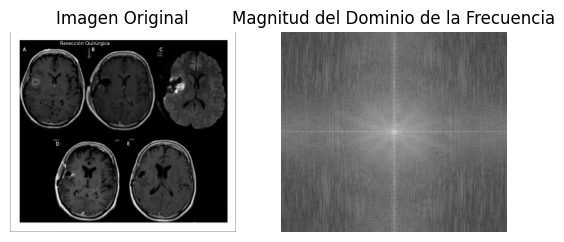

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Cargar imagen en escala de grises
ruta = "/content/drive/MyDrive/PDI/RM.jpg"

img = cv2.imread(ruta, 0)
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

# Dominio de la frecuencia
f_fourier = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
f_fourier_shift = np.fft.fftshift(f_fourier)
magnitud = 20 * np.log(cv2.magnitude(f_fourier_shift[:, :, 0], f_fourier_shift[:, :, 1]))
plt.subplot(1, 2, 2)
plt.imshow(magnitud, cmap='gray')
plt.title('Magnitud del Dominio de la Frecuencia')
plt.axis('off')

plt.show()

Se aplican filtros pasa bajas con diferentes radios:

Con r=20 la imagen se ve mucho menos nítida en comparación con r=80.

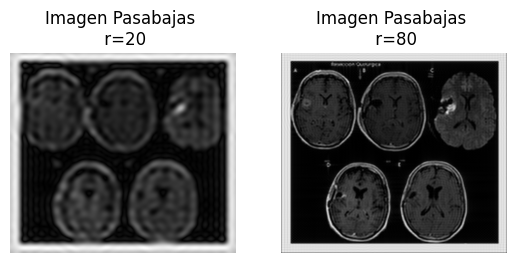

In [ ]:
# Filtos pasa bajas
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
mask = np.zeros((rows, cols, 2), np.uint8)
r1 = 20
mask[crow - r1:crow + r1, ccol - r1:ccol + r1] = 1
f_shift_filtrado = f_fourier_shift * mask
f_filtrado = np.fft.ifftshift(f_shift_filtrado)
img_pasabajas20 = cv2.idft(f_filtrado)
img_pasabajas20 = cv2.magnitude(img_pasabajas20[:, :, 0], img_pasabajas20[:, :, 1])
plt.subplot(1, 2, 1)
plt.imshow(img_pasabajas20, cmap='gray')
plt.title('Imagen Pasabajas \n r=20')
plt.axis('off')

r2 = 80
mask[crow - r2:crow + r2, ccol - r2:ccol + r2] = 1
f_shift_filtrado = f_fourier_shift * mask
f_filtrado = np.fft.ifftshift(f_shift_filtrado)
img_pasabajas80 = cv2.idft(f_filtrado)
img_pasabajas80 = cv2.magnitude(img_pasabajas80[:, :, 0], img_pasabajas80[:, :, 1])
plt.subplot(1, 2, 2)
plt.imshow(img_pasabajas80, cmap='gray')
plt.title('Imagen Pasabajas \n r=80')
plt.axis('off')

plt.show()

Se aplican dos diferentes filtros pasa altas:

Círculo: Presenta bordes completos y más nítidos.

Cruz: Los bordes se ven más borrosos y la imagen pierde detalles.

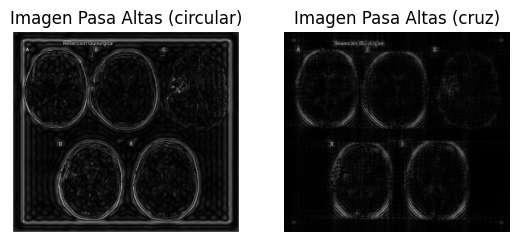

In [ ]:
# Filtro pasa altas
mask_circulo = np.ones((rows, cols, 2), np.uint8)
r = 20
mask_circulo[crow - r:crow + r, ccol - r:ccol + r] = 0
f_shift_filtrado = f_fourier_shift * mask_circulo
f_filtrado = np.fft.ifftshift(f_shift_filtrado)
img_pa_circ = cv2.idft(f_filtrado)
img_pa_circ = cv2.magnitude(img_pa_circ[:, :, 0], img_pa_circ[:, :, 1])
plt.subplot(1, 2, 1)
plt.imshow(img_pa_circ, cmap='gray')
plt.title('Imagen Pasa Altas (circular)')
plt.axis('off')

mask_cruz = np.ones((rows, cols, 2), np.uint8)
grosor = 20
mask_cruz[crow - grosor:crow + grosor, :, :] = 0
mask_cruz[:, ccol - grosor:ccol + grosor, :] = 0
f_shift_filtrado = f_fourier_shift * mask_cruz
f_filtrado = np.fft.ifftshift(f_shift_filtrado)
img_pa_cruz = cv2.idft(f_filtrado)
img_pa_cruz = cv2.magnitude(img_pa_cruz[:, :, 0], img_pa_cruz[:, :, 1])
plt.subplot(1, 2, 2)
plt.imshow(img_pa_cruz, cmap='gray')
plt.title('Imagen Pasa Altas (cruz)')
plt.axis('off')

plt.show()

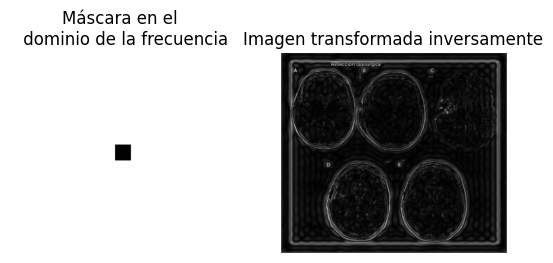

In [ ]:
# Máscara en el dominio de la frecuencia
mask_circulo = np.ones((rows, cols, 2), np.uint8)
r = 20
mask_circulo[crow - r:crow + r, ccol - r:ccol + r] = 0
mask_2d = np.ones((rows, cols), np.uint8)
mask_2d[crow - r:crow + r, ccol - r:ccol + r] = 0
plt.subplot(1, 2, 1)
plt.imshow(mask_2d, cmap='gray')
plt.title('Máscara en el \n dominio de la frecuencia')
plt.axis('off')

# Transformada Inversa
f_shift_filtrado = f_fourier_shift * mask_circulo
f_ishift = np.fft.ifftshift(f_shift_filtrado)
img_inv = cv2.idft(f_ishift)
img_inv = cv2.magnitude(img_inv[:, :, 0], img_inv[:, :, 1])
plt.subplot(1, 2, 2)
plt.imshow(img_inv, cmap='gray')
plt.title('Imagen transformada inversamente')
plt.axis('off')

plt.show()